Dataset Shape: (37349, 2)

Columns: ['text', 'intent']

First 5 rows:
                                                 text         intent
0   listen to westbam alumb allergic on google music      PlayMusic
1         add step to me to the 50 clásicos playlist  AddToPlaylist
2  i give this current textbook a rating value of...       RateBook
3               play the song little robin redbreast      PlayMusic
4  please add iris dement to my playlist this is ...  AddToPlaylist

Null values:
 text      0
intent    0
dtype: int64


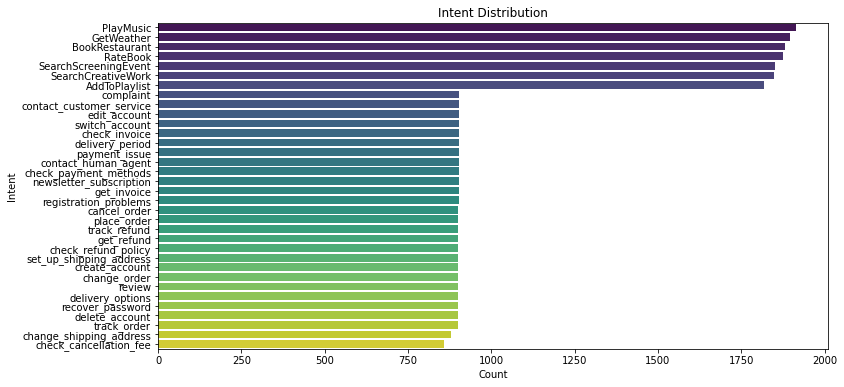


Unique Intents: 34
Most common intents:
 PlayMusic               1914
GetWeather              1896
BookRestaurant          1881
RateBook                1876
SearchScreeningEvent    1852
Name: intent, dtype: int64


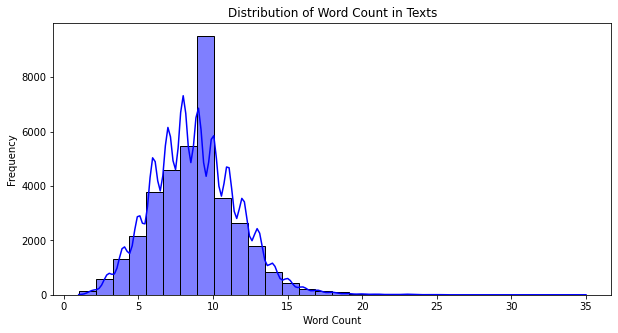


Average text length (characters): 46.550590377252405
Average word count: 8.799218185225843

Average word count per intent:
 intent
edit_account                 6.377630
PlayMusic                    7.063741
cancel_order                 7.531632
SearchCreativeWork           7.736871
change_shipping_address      7.821388
create_account               8.100000
contact_human_agent          8.125277
check_cancellation_fee       8.139860
place_order                  8.234184
change_order                 8.261111
newsletter_subscription      8.350333
delivery_options             8.404894
get_refund                   8.423333
check_payment_methods        8.427938
switch_account               8.517165
registration_problems        8.645233
set_up_shipping_address      8.653333
payment_issue                8.713969
track_order                  8.750834
SearchScreeningEvent         8.768898
RateBook                     8.858209
complaint                    8.862680
check_invoice                9.0

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/kaggle/input/intents-train/Train Data (3).csv")

# -------------------------------
# Basic Info
# -------------------------------
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:\n", df.head())
print("\nNull values:\n", df.isnull().sum())

# -------------------------------
# Intent Distribution
# -------------------------------
plt.figure(figsize=(12,6))
sns.countplot(y=df['intent'], order=df['intent'].value_counts().index, palette="viridis")
plt.title("Intent Distribution")
plt.xlabel("Count")
plt.ylabel("Intent")
plt.show()

print("\nUnique Intents:", df['intent'].nunique())
print("Most common intents:\n", df['intent'].value_counts().head())

# -------------------------------
# Text Length Analysis
# -------------------------------
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,5))
sns.histplot(df['word_count'], bins=30, kde=True, color="blue")
plt.title("Distribution of Word Count in Texts")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

print("\nAverage text length (characters):", df['text_length'].mean())
print("Average word count:", df['word_count'].mean())

# -------------------------------
# Sample per Intent
# -------------------------------
intent_length = df.groupby("intent")['word_count'].mean().sort_values()
print("\nAverage word count per intent:\n", intent_length)


In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Load dataset
df = pd.read_csv("/kaggle/input/intents-train/Train Data (3).csv")

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['intent'],
    test_size=0.2,
    random_state=42,
    stratify=df['intent']
)

# -------------------------------
# Baseline : TF-IDF + Logistic Regression
# -------------------------------
# Vectorize text using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Train Logistic Regression classifier
log_reg = LogisticRegression(max_iter=1000, solver="lbfgs", multi_class="auto")
log_reg.fit(X_train_tfidf, y_train)

# Predictions
y_pred_lr = log_reg.predict(X_test_tfidf)

# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.9852744310575636

Classification Report:
                           precision    recall  f1-score   support

           AddToPlaylist       0.99      1.00      0.99       364
          BookRestaurant       0.99      1.00      1.00       376
              GetWeather       0.98      1.00      0.99       379
               PlayMusic       0.98      0.97      0.98       383
                RateBook       1.00      1.00      1.00       375
      SearchCreativeWork       0.93      0.95      0.94       369
    SearchScreeningEvent       0.99      0.95      0.97       371
            cancel_order       0.98      0.95      0.97       180
            change_order       0.94      0.98      0.96       180
 change_shipping_address       0.99      0.99      0.99       176
  check_cancellation_fee       0.99      0.99      0.99       172
           check_invoice       0.95      0.99      0.97       181
   check_payment_methods       0.99      0.98      0.99       180
 

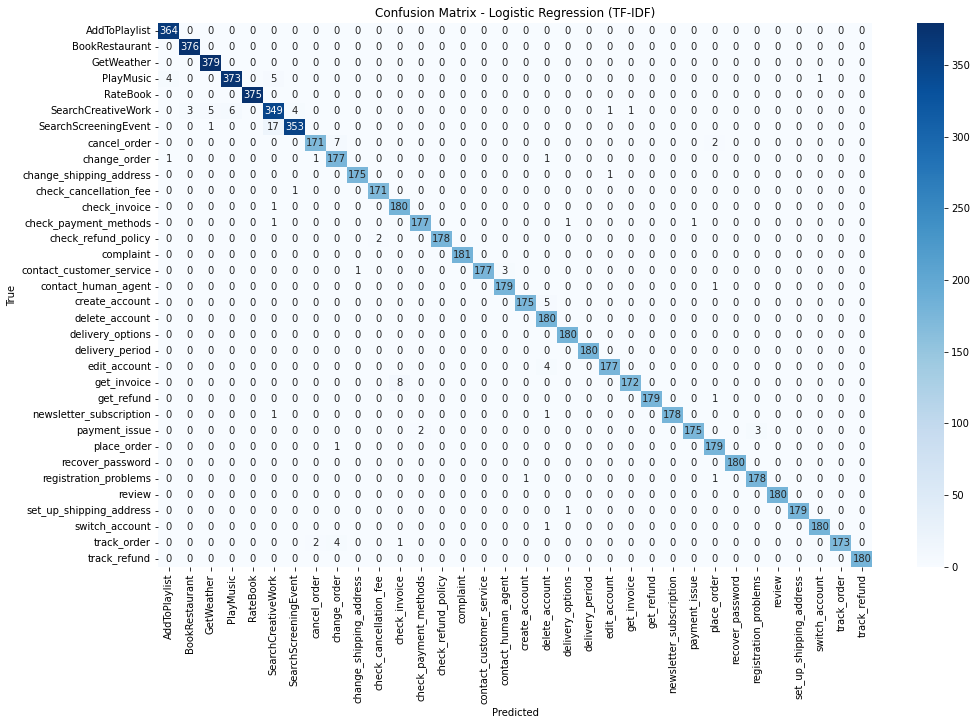

Macro F1-score: 0.986177916025681
Micro F1-score: 0.9852744310575636


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score

# -------------------------------
# Confusion Matrix Heatmap
# -------------------------------
cm = confusion_matrix(y_test, y_pred_lr, labels=log_reg.classes_)

plt.figure(figsize=(16,10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=log_reg.classes_,
            yticklabels=log_reg.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Logistic Regression (TF-IDF)")
plt.show()

# -------------------------------
# Macro & Micro F1 Scores
# -------------------------------
macro_f1 = f1_score(y_test, y_pred_lr, average="macro")
micro_f1 = f1_score(y_test, y_pred_lr, average="micro")

print("Macro F1-score:", macro_f1)
print("Micro F1-score:", micro_f1)
